# Used Car Price Prediction with Linear Regression

This notebook builds an interpretable **Linear Regression** baseline for used-car price prediction.

The focus is not only on the final score. I also want the workflow to be technically sound and easy to explain: validate the data, engineer a useful age feature, handle categorical variables correctly, avoid leakage, inspect residuals, and compare the single train/test result with cross-validation.

A second goal is to make the notebook portable between a local project folder and Kaggle without hard-coded personal paths.

## 1. Project Overview

The target is `Selling_Price`, a continuous variable, so this is a **supervised regression** problem.

I use Linear Regression as the first model because it gives a transparent baseline. Its coefficients can be inspected directly, and its assumptions make it useful for learning what the data supports before moving to more flexible algorithms.

This project is intentionally different from a housing-regression example: here the workflow has to deal with **categorical variables**, a **high-cardinality name field**, and simple **feature engineering** for vehicle age.

## 2. Problem Statement

The project is built around four practical questions:

1. Which vehicle characteristics are most clearly related to selling price?
2. How should categorical variables be represented without creating artificial numeric order?
3. How well does a linear baseline generalize to unseen cars?
4. What do residuals and cross-validation reveal that a single R² score cannot?

The supplied dataset does not specify a currency or price unit, so all error metrics are interpreted in the dataset's native price units rather than assigning a currency that is not documented.

## 3. Dataset and Feature Dictionary

The dataset contains vehicle characteristics and a selling-price target.

| Feature | Description |
|---|---|
| `Car_Name` | Car name / model label in the dataset |
| `Year` | Production year |
| `Selling_Price` | Sale price — **target** |
| `Present_Price` | Current listed/present price |
| `Kms_Driven` | Distance driven in kilometers |
| `Fuel_Type` | Fuel category |
| `Seller_Type` | Seller category |
| `Transmission` | Manual or automatic transmission |
| `Owner` | Number/category of previous owners |

`Car_Name` has many unique values relative to the size of the dataset. For this baseline I exclude it rather than create dozens of sparse dummy variables. A later model could revisit that choice with grouping, target-safe encoding, or a larger dataset.

## 4. Import Libraries

The imports are limited to what the workflow actually uses: data handling, visualization, preprocessing, model training, cross-validation, and statistical diagnostics.

To keep the portfolio visually consistent across projects, the main plots use the same restrained blue-and-green palette as the Boston Housing project.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

# Shared portfolio palette
PRIMARY = "#4C72B0"      # blue
SECONDARY = "#55A868"    # green
ACCENT = "#C44E52"       # reserved for warnings / emphasis
NEUTRAL = "#7F7F7F"      # gray

correlation_cmap = LinearSegmentedColormap.from_list(
    "portfolio_blue_green",
    [PRIMARY, "#F2F2F2", SECONDARY]
)

## 5. Load the Dataset

The loader checks both the local project layout and Kaggle's input directory. This keeps the notebook reproducible without embedding a machine-specific Windows path.

In [2]:
candidate_paths = [
    Path("car_data.csv"),
    Path("cardata.csv"),
    Path("../data/car_data.csv"),
    Path("../data/cardata.csv"),
]

kaggle_input = Path("/kaggle/input")
if kaggle_input.exists():
    candidate_paths.extend(kaggle_input.glob("**/car_data.csv"))
    candidate_paths.extend(kaggle_input.glob("**/cardata.csv"))

data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find car_data.csv. Place it in the project data folder "
        "or attach the dataset in Kaggle."
    )

print(f"Dataset loaded from: {data_path}")
df = pd.read_csv(data_path)
df.head()

Dataset loaded from: ..\data\car_data.csv


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 6. Initial Data Validation

Before changing anything, I check the dataset shape, column types, missing values, duplicates, and the number of unique values in each column. This is where preprocessing decisions should start.

In [3]:
print(f"Shape: {df.shape}")
print()
print("Data types:")
print(df.dtypes)

print()
print("Missing values:")
print(df.isna().sum())

print()
print(f"Duplicate rows: {df.duplicated().sum()}")

print()
print("Unique values per column:")
print(df.nunique())

Shape: (301, 9)

Data types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2

Unique values per column:
Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64


### Data-quality notes

The dataset has **301 rows and 9 columns**, no missing values, and **2 duplicate rows**.

I remove exact duplicates before the train/test split. This is a deterministic row-level cleaning step rather than a learned transformation, and it also reduces the chance that an identical record appears in both training and test data.

In [4]:
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (299, 9)


## 7. Feature Engineering: Vehicle Age

Raw production year is useful, but vehicle age is easier to interpret in a pricing model.

To keep the feature tied to the dataset rather than today's calendar year, I define a fixed reference year as one year after the newest production year in the data. The newest year is 2018, so the reference year becomes 2019.

This gives:

`Vehicle_Age = 2019 - Year`

A newer car therefore has a smaller age value, and the feature remains reproducible whenever the notebook is rerun.

In [5]:
REFERENCE_YEAR = int(df["Year"].max() + 1)
df["Vehicle_Age"] = REFERENCE_YEAR - df["Year"]

print(f"Reference year: {REFERENCE_YEAR}")
df[["Year", "Vehicle_Age"]].head()

Reference year: 2019


,Year,Vehicle_Age
0,2014,5
1,2013,6
2,2017,2
3,2011,8
4,2014,5


## 8. Exploratory Data Analysis

I keep the EDA focused on patterns that are useful for the linear baseline: target distribution, numeric relationships, category-level differences, and unusual values.

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,299,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,299.0,NaN,NaN,NaN,2013.615385,2.896868,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,299.0,NaN,NaN,NaN,4.589632,4.98424,0.1,0.85,3.51,6.0,35.0
Present_Price,299.0,NaN,NaN,NaN,7.541037,8.567887,0.32,1.2,6.1,9.84,92.6
Kms_Driven,299.0,NaN,NaN,NaN,36916.752508,39015.170352,500.0,15000.0,32000.0,48883.5,500000.0
Fuel_Type,299,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller_Type,299,2,Dealer,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,299,2,Manual,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,299.0,NaN,NaN,NaN,0.043478,0.24872,0.0,0.0,0.0,0.0,3.0
Vehicle_Age,299.0,NaN,NaN,NaN,5.384615,2.896868,1.0,3.0,5.0,7.0,16.0


### Target Distribution

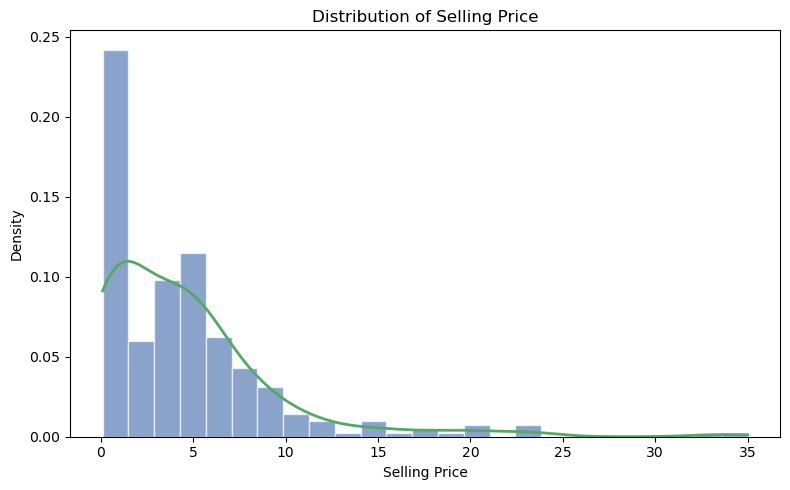

In [7]:
values = df["Selling_Price"].to_numpy()

plt.figure(figsize=(8, 5))

plt.hist(
    values,
    bins=25,
    density=True,
    alpha=0.65,
    color=PRIMARY,
    edgecolor="white"
)

if np.std(values) > 0:
    kde = stats.gaussian_kde(values)
    x_grid = np.linspace(values.min(), values.max(), 300)
    plt.plot(
        x_grid,
        kde(x_grid),
        color=SECONDARY,
        linewidth=2
    )

plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The target is right-skewed, with a small number of relatively high selling prices. I do **not** transform the target automatically. Linear Regression does not require the target itself to be normally distributed; residual behavior is the more relevant diagnostic for classical linear-model assumptions.

### Numeric Relationships

In [8]:
numeric_for_eda = ["Selling_Price", "Present_Price", "Kms_Driven", "Vehicle_Age", "Owner"]
correlation = df[numeric_for_eda].corr()
correlation.round(3)

,Selling_Price,Present_Price,Kms_Driven,Vehicle_Age,Owner
Selling_Price,1.000,0.876,0.029,-0.234,-0.088
Present_Price,0.876,1.000,0.205,0.054,0.010
Kms_Driven,0.029,0.205,1.000,0.526,0.089
Vehicle_Age,-0.234,0.054,0.526,1.000,0.182
Owner,-0.088,0.010,0.089,0.182,1.000


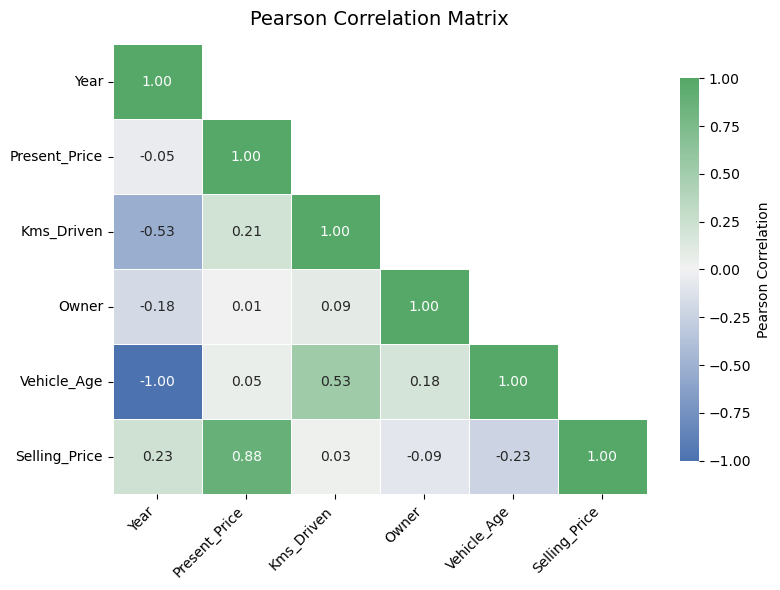

In [9]:
target = "Selling_Price"

# Pearson correlation is calculated only for numerical variables.
numeric_df = df.select_dtypes(include="number")

# Keep the target as the last column for easier visual interpretation.
df_ordered = pd.concat(
    [
        numeric_df.drop(columns=target),
        numeric_df[[target]]
    ],
    axis=1
)

# Pearson correlation is used because this project focuses
# on linear relationships.
corr_matrix = df_ordered.corr(method="pearson")

# Mask the upper triangle to avoid showing duplicate information.
mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool),
    k=1
)

plt.figure(figsize=(8, 6), dpi=100)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap=correlation_cmap,
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=False,
    annot_kws={"size": 10},
    cbar_kws={
        "shrink": 0.85,
        "label": "Pearson Correlation"
    }
)

plt.title(
    "Pearson Correlation Matrix",
    fontsize=14,
    pad=14
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

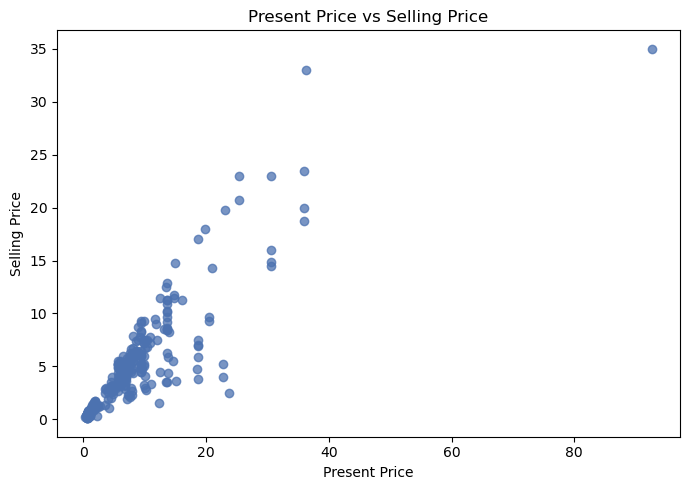

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"],
    alpha=0.75,
    color=PRIMARY
)

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")
plt.tight_layout()
plt.show()

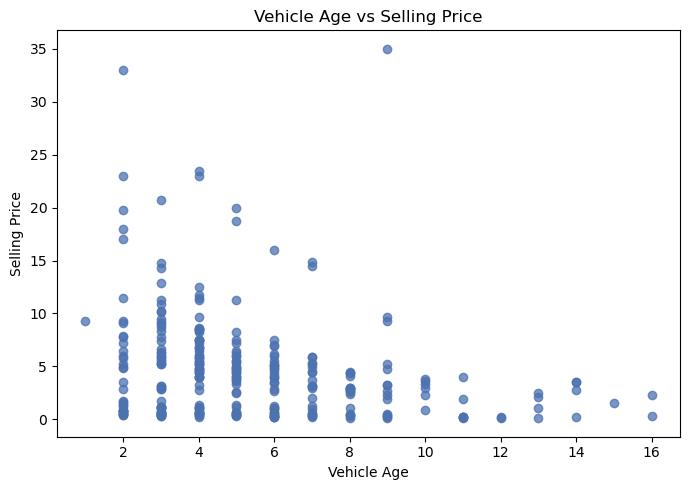

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df["Vehicle_Age"],
    df["Selling_Price"],
    alpha=0.75,
    color=PRIMARY
)

plt.xlabel("Vehicle Age")
plt.ylabel("Selling Price")
plt.title("Vehicle Age vs Selling Price")
plt.tight_layout()
plt.show()

`Present_Price` has the strongest linear relationship with the target among the numeric variables in this dataset. Vehicle age shows a negative relationship, which is directionally consistent with depreciation, although the relationship is not perfectly linear.

### Categorical Relationships

In [12]:
for column in ["Fuel_Type", "Seller_Type", "Transmission"]:
    summary = (
        df.groupby(column, observed=False)["Selling_Price"]
        .agg(["count", "mean", "median"])
        .sort_values("mean", ascending=False)
    )
    print()
    print(column)
    display(summary.round(3))


Fuel_Type


,count,mean,median
Fuel_Type,,,
Diesel,58,10.103,7.60
Petrol,239,3.264,2.65
CNG,2,3.100,3.10



Seller_Type


,count,mean,median
Seller_Type,,,
Dealer,193,6.632,5.250
Individual,106,0.871,0.515



Transmission


,count,mean,median
Transmission,,,
Automatic,39,9.072,5.75
Manual,260,3.917,3.25


These summaries are descriptive, not causal. Category averages can reflect other differences in the vehicles, such as present price, age, or mileage.

## 9. Outlier Review

Instead of clipping or deleting observations automatically, I use the IQR rule to **flag** unusual numeric values.

This keeps the baseline faithful to the observed data and avoids changing the test distribution before the model has even been evaluated.

In [13]:
def iqr_outlier_summary(data, columns):
    rows = []
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (data[column] < lower) | (data[column] > upper)
        rows.append({
            "feature": column,
            "lower_bound": lower,
            "upper_bound": upper,
            "flagged_rows": int(mask.sum()),
        })
    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(
    df,
    ["Selling_Price", "Present_Price", "Kms_Driven", "Vehicle_Age"],
)
outlier_summary.round(3)

,feature,lower_bound,upper_bound,flagged_rows
0,Selling_Price,-6.875,13.725,16
1,Present_Price,-11.760,22.800,14
2,Kms_Driven,-35825.250,99708.750,8
3,Vehicle_Age,-3.000,13.000,7


## 10. Preparing Features and Target

For the baseline model:

- `Selling_Price` is the target.
- `Car_Name` is excluded because it has high cardinality relative to the dataset size.
- `Year` is replaced by the engineered `Vehicle_Age` feature.
- Categorical columns remain as strings for now; they will be encoded **inside the pipeline** after the train/test split.

In [14]:
model_df = df.drop(columns=["Car_Name", "Year"]).copy()

X = model_df.drop(columns="Selling_Price")
y = model_df["Selling_Price"]

categorical_features = ["Fuel_Type", "Seller_Type", "Transmission"]
numeric_features = ["Vehicle_Age", "Present_Price", "Kms_Driven", "Owner"]

print("Features:", list(X.columns))
print("Target:", y.name)

Features: ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Vehicle_Age']
Target: Selling_Price


## 11. Train / Test Split

I reserve 20% of the cleaned data for final testing. Any learned preprocessing happens only after this split.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 239
Test rows: 60


## 12. Categorical Encoding and Pipeline

The original notebook replaced categories with values such as `2`, `3`, and `4`. That creates an artificial numeric order: for example, it would imply that one fuel type is mathematically "larger" than another.

For nominal categories, **One-Hot Encoding** is more appropriate.

I choose intuitive reference categories for interpretation:

- `Petrol` for fuel type,
- `Dealer` for seller type,
- `Manual` for transmission.

The remaining category coefficients are interpreted relative to those references while holding the other model features constant.

Feature scaling is not required for ordinary least-squares Linear Regression, so I leave numeric variables in their original units.

In [16]:
encoder = OneHotEncoder(
    categories=[
        ["Petrol", "Diesel", "CNG"],
        ["Dealer", "Individual"],
        ["Manual", "Automatic"],
    ],
    drop="first",
    handle_unknown="ignore",
)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(categories=[['Petrol',
                                                                             'Diesel',
                                                                             'CNG'],
                                                                            ['Dealer',
                                                                             'Individual'],
                                                                            ['Manual',
                                                                             'Automatic']],
                                                                drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Seller_Type',
                                                   'Transmission']),
                                                 ('numeric', 'passthrough',
                                                  ['Vehicle_Age',
                                                   'Present_Price',
                                                   'Kms_Driven', 'Owner'])])),
                ('regressor', LinearRegression())])

## 13. Linear Regression — Short Review

Linear Regression models the target as a weighted sum of the input features:

\[
\hat{y} = \beta_0 + \beta_1x_1 + \cdots + \beta_px_p
\]

The fitted coefficients are chosen by **Ordinary Least Squares (OLS)** to minimize the sum of squared residuals.

A residual is:

\[
e_i = y_i - \hat{y}_i
\]

For this project, the important assumptions are not checked by looking at the target distribution alone. The residuals are more informative for diagnosing linearity, constant variance, and departures from normality.

## 14. Train the Model

In [17]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 15. Evaluation Metrics

I report several metrics because each emphasizes something different:

- **MAE**: average absolute error; easy to interpret.
- **MSE**: squared error; gives more weight to larger mistakes.
- **RMSE**: square root of MSE; back in the target's original units.
- **R²**: proportion of target variation explained relative to predicting the mean.
- **Adjusted R²**: R² adjusted for the number of model features.

Lower is better for MAE, MSE, and RMSE. Higher is generally better for R² and Adjusted R².

In [18]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

n_test = len(y_test)
p_features = model.named_steps["preprocessor"].transform(X_train).shape[1]
adjusted_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p_features - 1)

metrics_table = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²", "Adjusted R²"],
    "Value": [mae, mse, rmse, r2, adjusted_r2],
})
metrics_table.round(4)

,Metric,Value
0,MAE,1.4729
1,MSE,6.3708
2,RMSE,2.5240
3,R²,0.7528
4,Adjusted R²,0.7140


### Actual vs Predicted

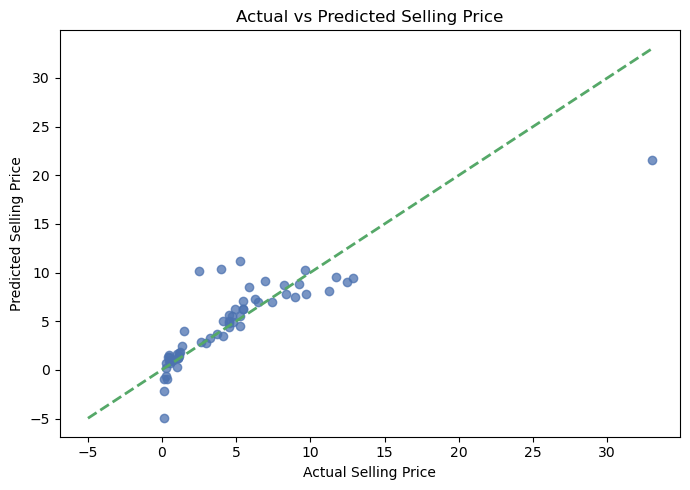

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.75,
    color=PRIMARY
)

line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--",
    color=SECONDARY,
    linewidth=2
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")
plt.tight_layout()
plt.show()

## 16. Residual Diagnostics

A single score can hide useful structure. Residual plots help show whether errors are centered around zero, whether variance changes across the prediction range, and whether the tails depart strongly from normality.

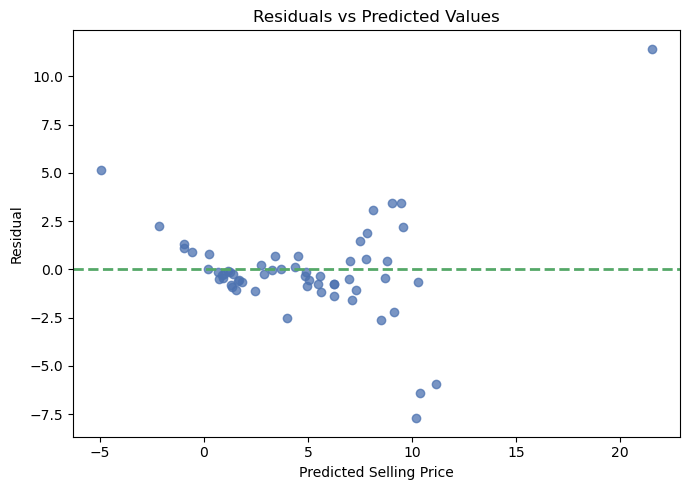

In [20]:
residuals = y_test.to_numpy() - y_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.75,
    color=PRIMARY
)

plt.axhline(
    0,
    linestyle="--",
    color=SECONDARY,
    linewidth=2
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

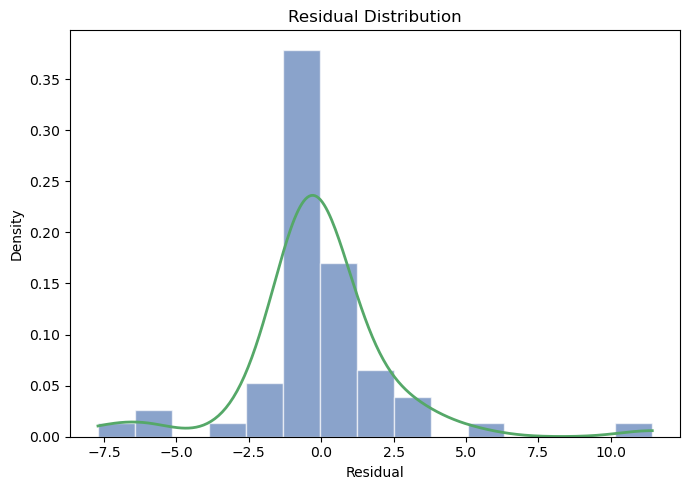

In [21]:
plt.figure(figsize=(7, 5))

plt.hist(
    residuals,
    bins=15,
    density=True,
    alpha=0.65,
    color=PRIMARY,
    edgecolor="white"
)

if np.std(residuals) > 0:
    residual_kde = stats.gaussian_kde(residuals)
    x_grid = np.linspace(residuals.min(), residuals.max(), 300)

    plt.plot(
        x_grid,
        residual_kde(x_grid),
        color=SECONDARY,
        linewidth=2
    )

plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()

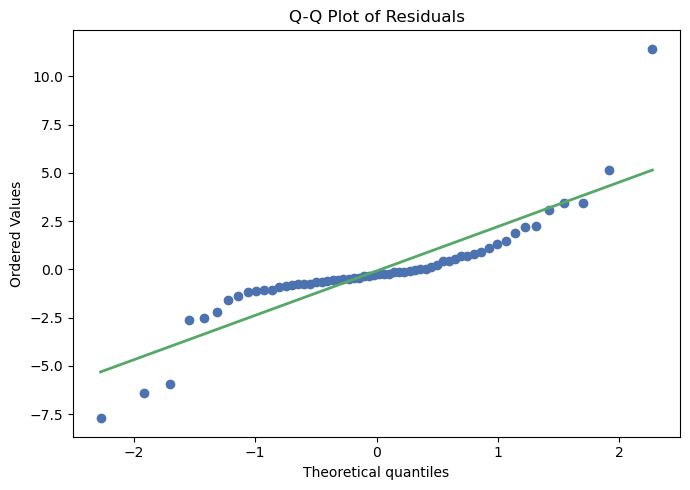

In [22]:
plt.figure(figsize=(7, 5))

stats.probplot(
    residuals,
    dist="norm",
    plot=plt
)

ax = plt.gca()

# Points
ax.get_lines()[0].set_color(PRIMARY)
ax.get_lines()[0].set_markerfacecolor(PRIMARY)
ax.get_lines()[0].set_markeredgecolor(PRIMARY)

# Reference line
ax.get_lines()[1].set_color(SECONDARY)
ax.get_lines()[1].set_linewidth(2)

plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

The diagnostics should be read together with the metrics. A strong R² does not automatically mean every Linear Regression assumption is satisfied, and a few large errors can still matter in a small dataset.

## 17. Model Coefficients

Because preprocessing happens inside the pipeline, I extract the final transformed feature names directly from the fitted preprocessor rather than hard-coding coefficients.

In [23]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefficients = model.named_steps["regressor"].coef_
intercept = model.named_steps["regressor"].intercept_

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
}).sort_values("Coefficient", key=np.abs, ascending=False)

print(f"Intercept: {intercept:.4f}")
coefficient_table.reset_index(drop=True).round(6)

Intercept: 3.4310


,Feature,Coefficient
0,categorical__Transmission_Automatic,1.572125
1,categorical__Fuel_Type_Diesel,1.448489
2,categorical__Seller_Type_Individual,-1.301377
3,categorical__Fuel_Type_CNG,-0.690622
4,numeric__Owner,0.642856
5,numeric__Present_Price,0.437187
6,numeric__Vehicle_Age,-0.331041
7,numeric__Kms_Driven,-0.000011


### Interpreting the coefficients

A numeric coefficient is the expected change in predicted selling price for a one-unit increase in that feature, **holding the other model inputs constant**.

For one-hot encoded variables, each coefficient is interpreted relative to its reference category. For example, the transmission coefficient compares `Automatic` with the reference category `Manual`, all else equal.

Raw coefficient magnitudes should not be treated as a feature-importance ranking because the numeric features use different units and scales.

## 18. Cross-Validation

The held-out test set is useful, but one split can be unusually easy or difficult. I therefore evaluate the **entire pipeline** with shuffled 5-fold cross-validation.

Encoding is fitted separately inside each training fold, which keeps the evaluation leakage-safe.

In [24]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=cv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
    },
)

cv_summary = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Mean": [
        cv_results["test_r2"].mean(),
        (-cv_results["test_mae"]).mean(),
        np.sqrt(-cv_results["test_mse"]).mean(),
    ],
    "Std": [
        cv_results["test_r2"].std(),
        (-cv_results["test_mae"]).std(),
        np.sqrt(-cv_results["test_mse"]).std(),
    ],
})

cv_summary.round(4)

,Metric,Mean,Std
0,R²,0.8520,0.0541
1,MAE,1.2314,0.1687
2,RMSE,1.8695,0.4781


## 19. Example Prediction

The new observation is passed to the same fitted pipeline in raw form. There is no manual encoding, scaling, or hand-written equation, which reduces the chance of preprocessing inconsistencies.

In [25]:
sample_car = pd.DataFrame([{
    "Vehicle_Age": 5,
    "Present_Price": 5.59,
    "Kms_Driven": 27000,
    "Fuel_Type": "Petrol",
    "Seller_Type": "Dealer",
    "Transmission": "Manual",
    "Owner": 0,
}])

sample_prediction = model.predict(sample_car)[0]
print(f"Predicted selling price: {sample_prediction:.3f} dataset price units")

Predicted selling price: 3.936 dataset price units


## 20. Results

With an 80/20 split and `random_state=42`, this baseline produces approximately:

- **MAE:** 1.47
- **MSE:** 6.37
- **RMSE:** 2.52
- **R²:** 0.753
- **Adjusted R²:** 0.714

Across 5 shuffled folds, the mean results are approximately:

- **R²:** 0.852
- **MAE:** 1.23
- **RMSE:** 1.87

The cross-validation average is stronger than the single held-out split, which is a good reminder that performance can vary noticeably depending on which observations land in the test set. On a dataset this small, I would report both rather than presenting one number as definitive.

## 21. Conclusion

Linear Regression gives a useful first benchmark for this dataset, especially because `Present_Price` carries a strong linear signal and the categorical variables can be handled cleanly with one-hot encoding.

The project also highlights several workflow decisions that matter more than they may first appear:

- nominal categories should not be assigned arbitrary ordered numbers,
- exact duplicates should be handled before evaluation,
- outliers should be investigated rather than clipped by default,
- preprocessing belongs inside a pipeline,
- and predictions should be made through the same fitted pipeline used during training.

The baseline is interpretable and reasonably predictive, but the residuals and split-to-split variation leave room for models that can capture nonlinear relationships and interactions.

## 22. Future Improvements

The next experiments I would prioritize are:

1. **Ridge, Lasso, and Elastic Net** for regularized linear baselines.
2. **Polynomial features** for nonlinear effects such as depreciation curves.
3. Tree-based models such as **Random Forest** and **Gradient Boosting**.
4. A more deliberate treatment of `Car_Name`, for example grouping rare models or using leakage-safe encoding.
5. Repeated cross-validation for a more stable estimate on this small dataset.
6. Influence diagnostics to study observations with unusually large leverage or residuals.
7. Hyperparameter tuning only after a fair baseline comparison is established.

## 23. Technologies & Libraries

- Python
- NumPy
- pandas
- Matplotlib
- Seaborn
- SciPy
- scikit-learn
- Jupyter Notebook

### Core concepts used

- Supervised Learning
- Linear Regression / OLS
- Feature Engineering
- One-Hot Encoding
- High-Cardinality Features
- Train/Test Split
- Pipeline
- Leakage Prevention
- MAE / MSE / RMSE / R² / Adjusted R²
- Residual Analysis
- Cross-Validation
- Coefficient Interpretation

## 24. GitHub ↔ Kaggle

### GitHub Repository
[GitHub Repository](https://github.com/Anahita-Pouladi/car-price-prediction-linear-regression)

### Kaggle Notebook
[Kaggle Notebook](https://www.kaggle.com/code/anahitapouladi/car-price-prediction-linear-regression)

Keeping these links in one place makes it easy to connect the full project documentation on GitHub with the executable notebook on Kaggle.

---

## What I Learned

The biggest improvement in this version was not a more complicated model. It was making the workflow internally consistent.

The original approach mixed manual category numbering, target transformation, scaling, and prediction steps in ways that made the final score harder to interpret. Rebuilding the baseline with a single pipeline made the logic much clearer: raw data goes in, the right encoding happens in one place, the model is evaluated on the original target scale, and new predictions follow exactly the same path.

That is the standard I want to keep for the rest of the portfolio: simple first, reproducible throughout, and every preprocessing decision easy to explain.